## Import all the necessary config files

In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)
#if you get an error here you propoably didnt close the parameters excel sheet

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'Run'

## Run the coral model

In [3]:
print(growth_rate_df)

   CoralType  GrowthRate_cm_per_year
0  Branching                     2.9
1    Foliose                     2.5
2      Other                     1.0


In [4]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear) # no PDS_df because it’s a placeholder. It basically asks a user to link SOME data frame to it. Same as run_model_n_times(n_iterations) simply tells a user that there should be some number in those brackets that will become the number of iterations. 

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,2.600000,7.300000,8.000000,17.900000
1,1,2.386899,7.236069,7.971693,17.594661
2,2,2.175225,7.256116,8.144873,17.576215
3,3,2.069958,7.366933,8.276820,17.713711
4,4,2.015118,7.615191,8.557993,18.188302
5,5,2.270652,7.975307,8.791060,19.037019
6,6,2.597901,8.390661,9.038362,20.026924
7,7,3.052646,8.906149,9.382465,21.341260
8,8,3.556774,9.557474,9.758965,22.873213
9,9,4.110578,10.231264,10.093643,24.435484


## Plot the change in total coral cover over the years

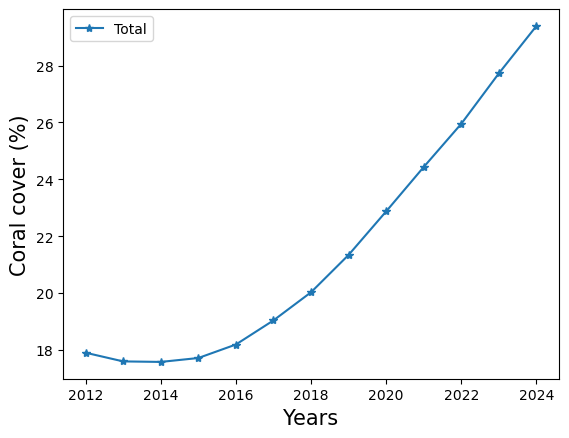

In [5]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [6]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot,ds_mean_monthly_ds,ds_loss_pct,ds_recovered_pct
0,0,89.100000,43.300000,2.400000,4.000000,0.800000,36.100000,36.800000,4.000000,5.000000,17.900000,45.800000,107.0,NaN,NaN,NaN
1,1,82.405339,40.878961,2.277344,4.548385,0.738281,33.314950,33.960946,3.076173,4.489259,17.594661,41.526378,100.0,0.0,0.0,0.125
2,2,82.423785,41.492540,2.331291,5.232371,0.739048,33.189829,33.996190,2.566138,4.368918,17.576215,40.931246,100.0,0.0,0.0,0.125
3,3,82.286289,41.872615,2.381949,5.729742,0.739688,33.021236,34.025666,2.140302,4.247706,17.713711,40.413673,100.0,0.0,0.0,0.125
4,4,81.811698,41.850611,2.415541,6.074359,0.740226,32.620484,34.050410,1.784882,4.125795,18.188302,39.961087,100.0,0.0,0.0,0.125
5,5,80.962981,41.400070,2.429622,6.263152,0.740680,31.966615,34.071275,1.488313,4.003323,19.037019,39.562911,100.0,0.0,0.0,0.125
6,6,79.973076,40.762883,2.434196,6.383145,0.741063,31.204478,34.088897,1.240902,3.880394,20.026924,39.210193,100.0,0.0,0.0,0.125
7,7,78.658740,39.763265,2.417788,6.411150,0.741388,30.192939,34.103842,1.034539,3.757095,21.341260,38.895475,100.0,0.0,0.0,0.125
8,8,77.126787,38.514302,2.386235,6.367991,0.741664,29.018412,34.116553,0.862437,3.633495,22.873213,38.612485,100.0,0.0,0.0,0.125
9,9,75.564516,37.208570,2.350766,6.288868,0.741899,27.827037,34.127373,0.718925,3.509647,24.435484,38.355946,100.0,0.0,0.0,0.125


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

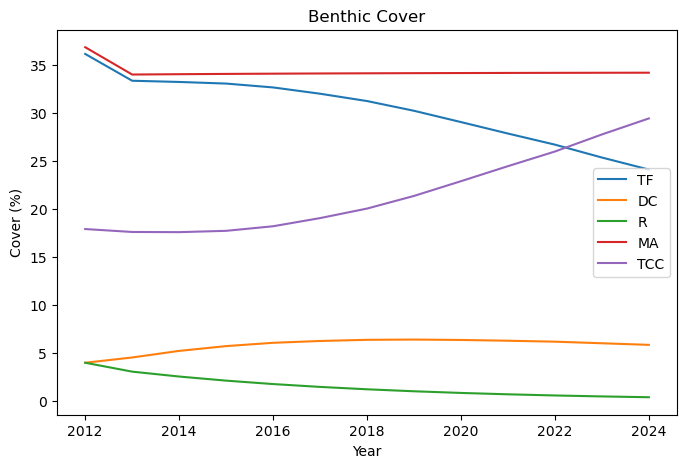

In [7]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [8]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots - please enter the years (within model range) for each plot

(0, 3, 6, 10)


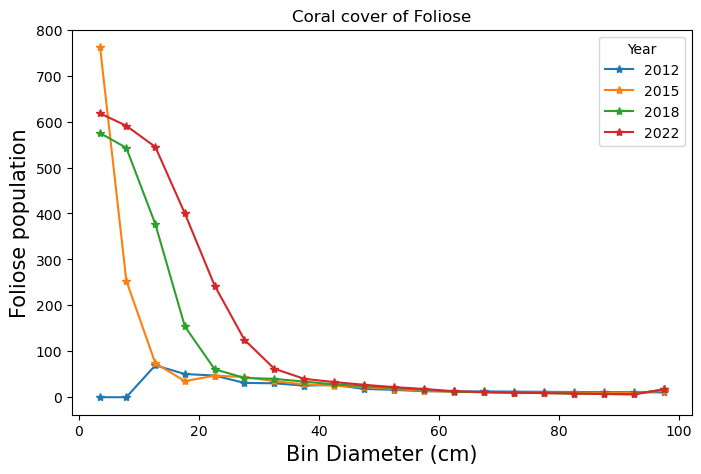

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2012, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

(0, 3, 6, 10)


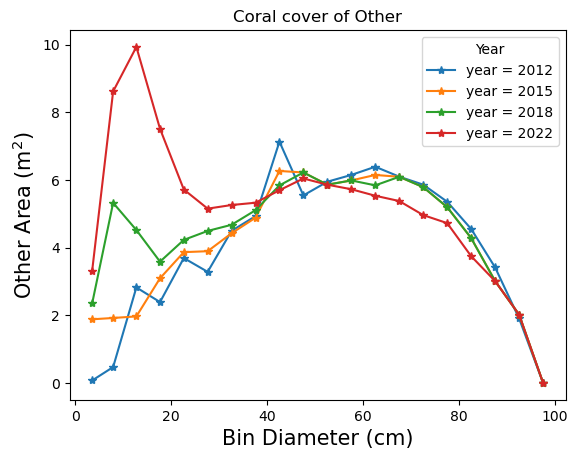

In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2012, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

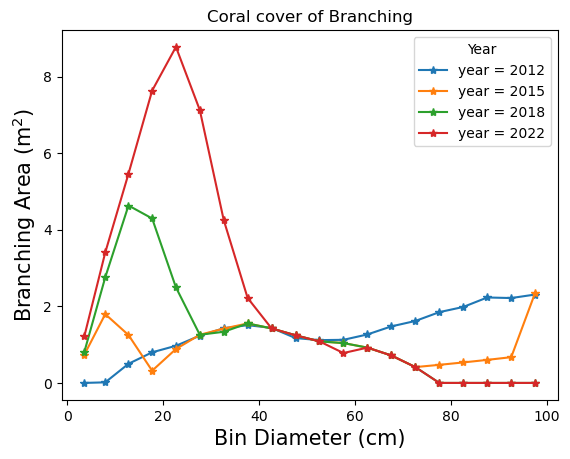

In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2012, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

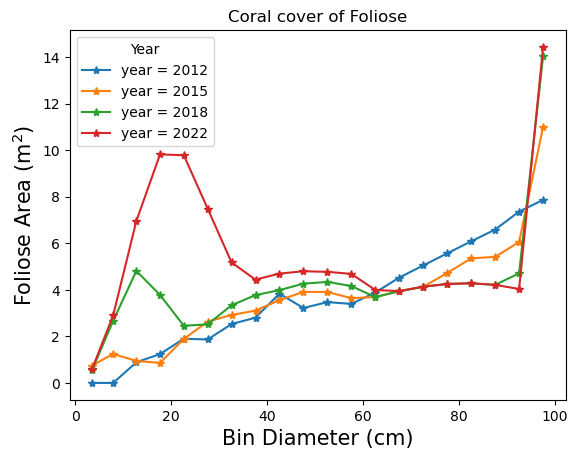

In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2012, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

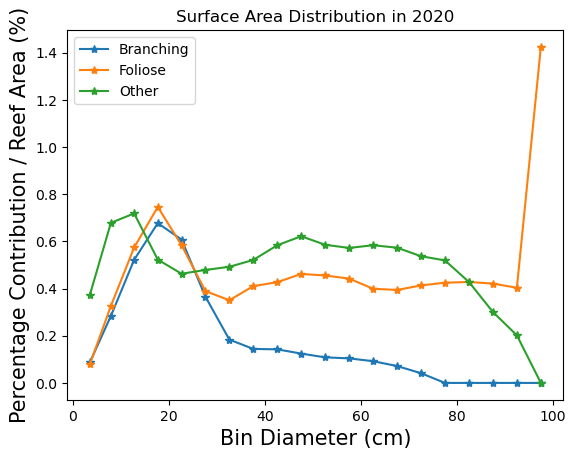

In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

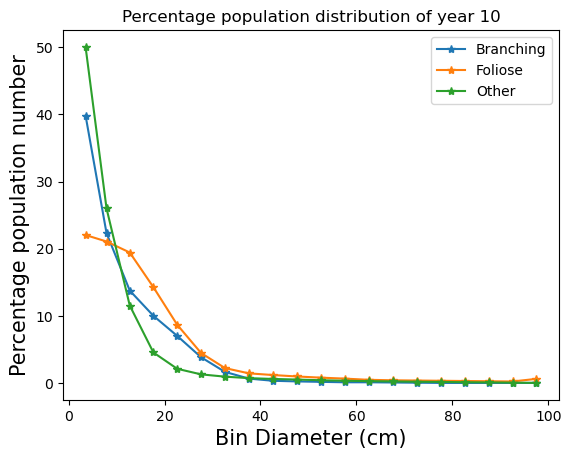

In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2022
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

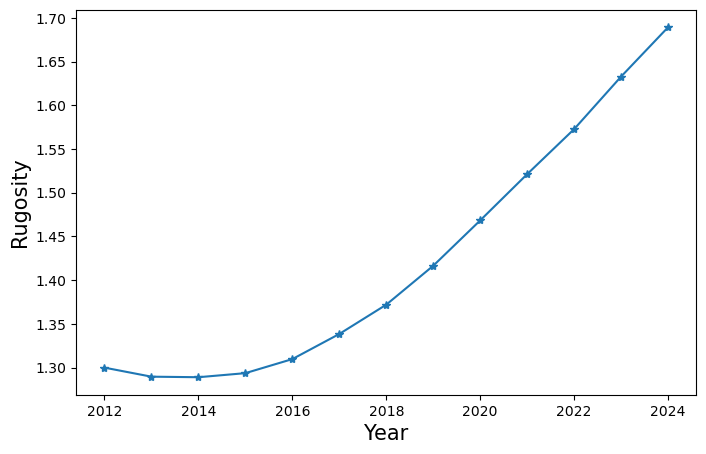

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

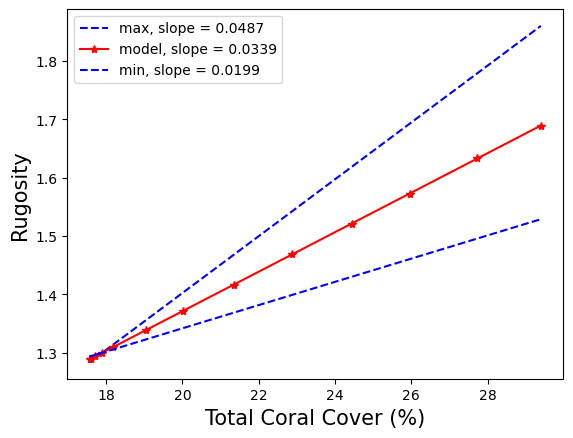

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

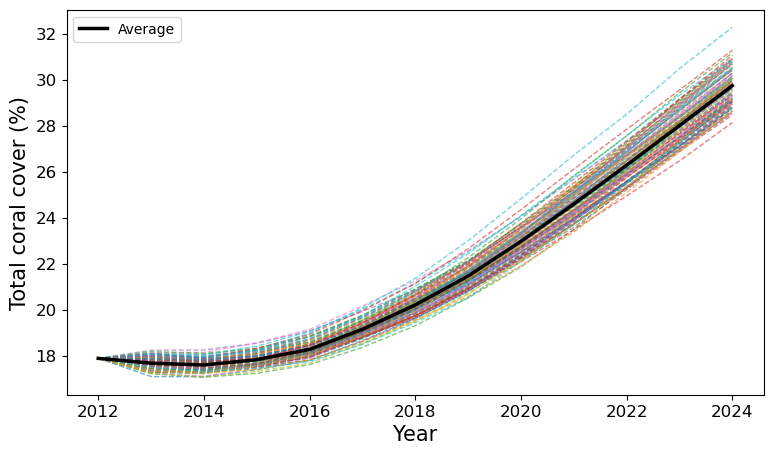

In [18]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [19]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,...,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000
1,1,17.859635,17.695192,17.231292,17.777462,17.539487,17.799552,17.562263,17.585506,17.861893,...,17.344684,17.451301,17.563049,17.587003,17.588967,17.508537,17.568252,17.251417,17.508660,17.693756
2,2,17.746720,17.608332,17.082235,17.712820,17.437933,17.676281,17.374002,17.542395,17.869044,...,17.308143,17.388366,17.562595,17.453110,17.493164,17.544812,17.453420,17.086048,17.326137,17.613227
3,3,17.929307,17.693467,17.251436,17.833002,17.672260,17.823100,17.611626,17.845092,18.123580,...,17.693717,17.657037,17.861308,17.657478,17.660777,17.852616,17.594171,17.331527,17.470935,17.844000
4,4,18.403895,17.992540,17.633681,18.155017,18.003948,18.225235,18.007871,18.234868,18.691552,...,18.274870,18.126400,18.483616,18.136736,18.209736,18.254362,17.998875,17.700154,17.766190,18.292281
5,5,19.291780,18.824746,18.379142,18.903231,18.826722,18.953848,18.920865,19.188320,19.588303,...,19.277183,19.115881,19.429845,19.068362,19.056963,19.172553,18.951441,18.549621,18.507701,19.163207
6,6,20.388558,19.752798,19.315677,19.768572,19.742502,20.044749,19.872003,20.286427,20.685400,...,20.410955,20.163985,20.639403,20.234170,20.127452,20.203031,20.115491,19.505347,19.454901,20.221408
7,7,21.732391,20.934615,20.524533,20.843761,20.928840,21.265615,21.085384,21.708621,22.081828,...,21.899764,21.377804,22.015630,21.617537,21.268862,21.413592,21.411828,20.695474,20.530522,21.476640
8,8,23.302374,22.266947,21.876157,22.095526,22.324694,22.770108,22.543124,23.244158,23.739536,...,23.536350,22.903060,23.631938,23.335030,22.701000,22.861274,23.014048,22.180941,22.116511,22.980533
9,9,25.117374,23.725686,23.497537,23.479423,23.850171,24.343119,24.148527,24.879455,25.426737,...,25.297796,24.504908,25.366014,25.121551,24.332355,24.356811,24.694175,23.712082,23.716491,24.600980


In [20]:
# Real data input should be saved in the coral_data_and_custom_parameters.xlsx file
# Load the Excel file into a DataFrame

# Load Excel
real_df_raw = pd.read_excel("coral_data_and_custom_parameters.xlsx", sheet_name="Real_Cover")

# Fill + mask (returns a tuple)
real_df, created = fill_nans_columnwise(
    real_df_raw,
    year_col='Year',
    make_full_years=False,
    fallback='mean',
    return_mask=True
)

# Make Year integer-like for display
real_df['Year'] = pd.to_numeric(real_df['Year'], errors='coerce').round().astype('Int64')

value_cols = [c for c in real_df.columns if c != 'Year']

# Build red-highlight styles
styles = created.reindex_like(real_df).replace({True: 'color: red', False: ''})

# Display with exactly 2 decimals (and integer Year)
styler = (
    real_df.style
           .format({c: '{:.2f}' for c in value_cols})
           .format({'Year': '{:.0f}'})
           .apply(lambda _: styles, axis=None)
)
display(styler)


,Year,RealBranching_Area (%),RealFoliose_Area (%),RealOther_Area (%)
0,2005,2.600000,7.300000,8.000000
1,2006,2.300000,6.000000,5.400000
2,2007,2.100000,8.900000,7.800000
3,2008,3.400000,6.300000,8.000000
4,2009,1.800000,7.600000,8.000000
5,2010,1.500000,5.600000,6.200000
6,2011,0.300000,3.400000,7.000000
7,2012,1.000000,2.900000,5.200000
8,2013,0.500000,4.200000,6.100000
9,2014,1.700000,5.400000,6.700000


## Run the model through a number iterations for all parameters and export results

In [21]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.600000          7.300000        8.000000   
1      1            2.362846          7.437033        7.781234   
2      2            2.135270          7.410162        7.892662   
3      3            2.012550          7.494084        8.057203   
4      4            1.918449          7.764464        8.338376   
..   ...                 ...               ...             ...   
8      8            3.625398          9.669352        8.886191   
9      9            4.226817         10.359626        9.125639   
10    10            4.851895         11.157808        9.342900   
11    11            5.520269         11.929370        9.506459   
12    12            6.162332         12.679536        9.824349   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               17.900000                89.100000                43.300000   
1               17.581113        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

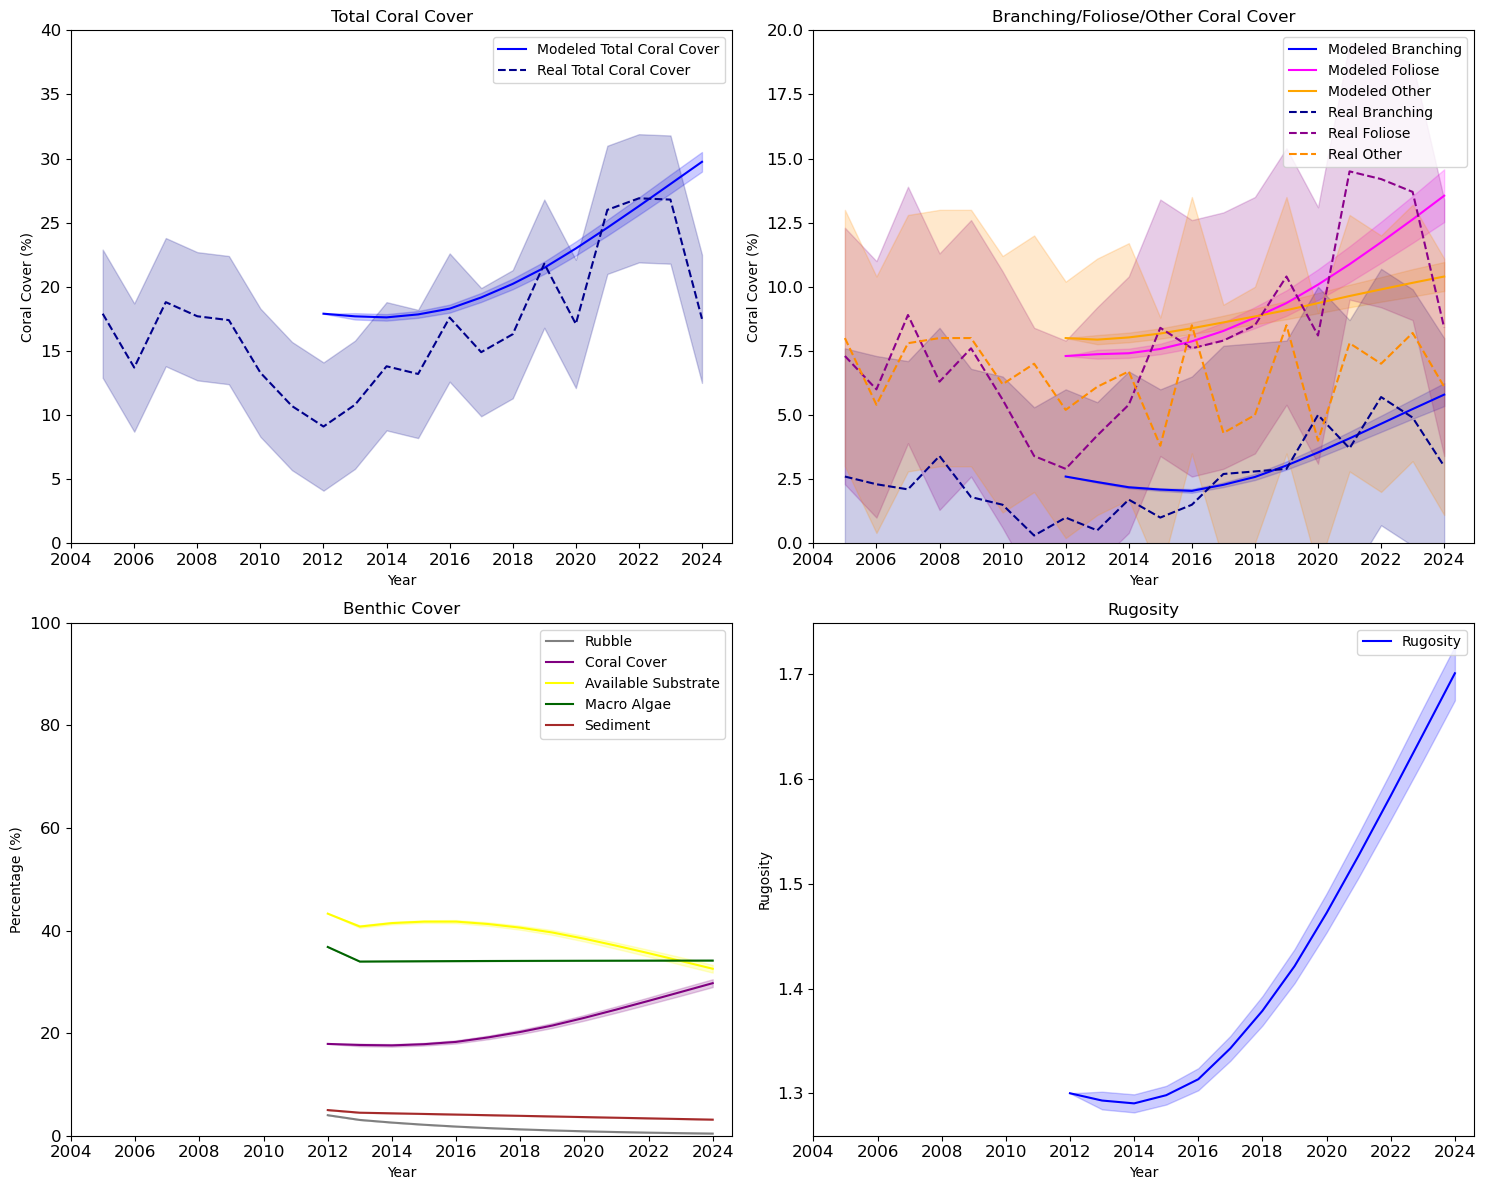

In [22]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, (average_total - std_dev_total).astype(float), (average_total + std_dev_total).astype(float), color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'].astype(float), real_df['Total_Coral_Cover (%)'].astype(float), label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'].astype(float), (real_df['Total_Coral_Cover (%)'].astype(float) - real_total_margin), (real_df['Total_Coral_Cover (%)'].astype(float) + real_total_margin), color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 40)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, (average_branching - std_dev_branching).astype(float), (average_branching + std_dev_branching).astype(float), color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, (average_foliose - std_dev_foliose).astype(float), (average_foliose + std_dev_foliose).astype(float), color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, (average_other - std_dev_other).astype(float), (average_other + std_dev_other).astype(float), color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealBranching_Area (%)'].astype(float), label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealBranching_Area (%)'].astype(float) - real_branching_margin), (real_df['RealBranching_Area (%)'].astype(float) + real_branching_margin), color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealFoliose_Area (%)'].astype(float), label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealFoliose_Area (%)'].astype(float) - real_foliose_margin), (real_df['RealFoliose_Area (%)'].astype(float) + real_foliose_margin), color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealOther_Area (%)'].astype(float), label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealOther_Area (%)'].astype(float) - real_other_margin), (real_df['RealOther_Area (%)'].astype(float) + real_other_margin), color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 20
                  )
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# After your plotting code:
# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

## Create bubble plot for population distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12]
Actual years for display: [2012, 2014, 2016, 2018, 2020, 2022, 2024]


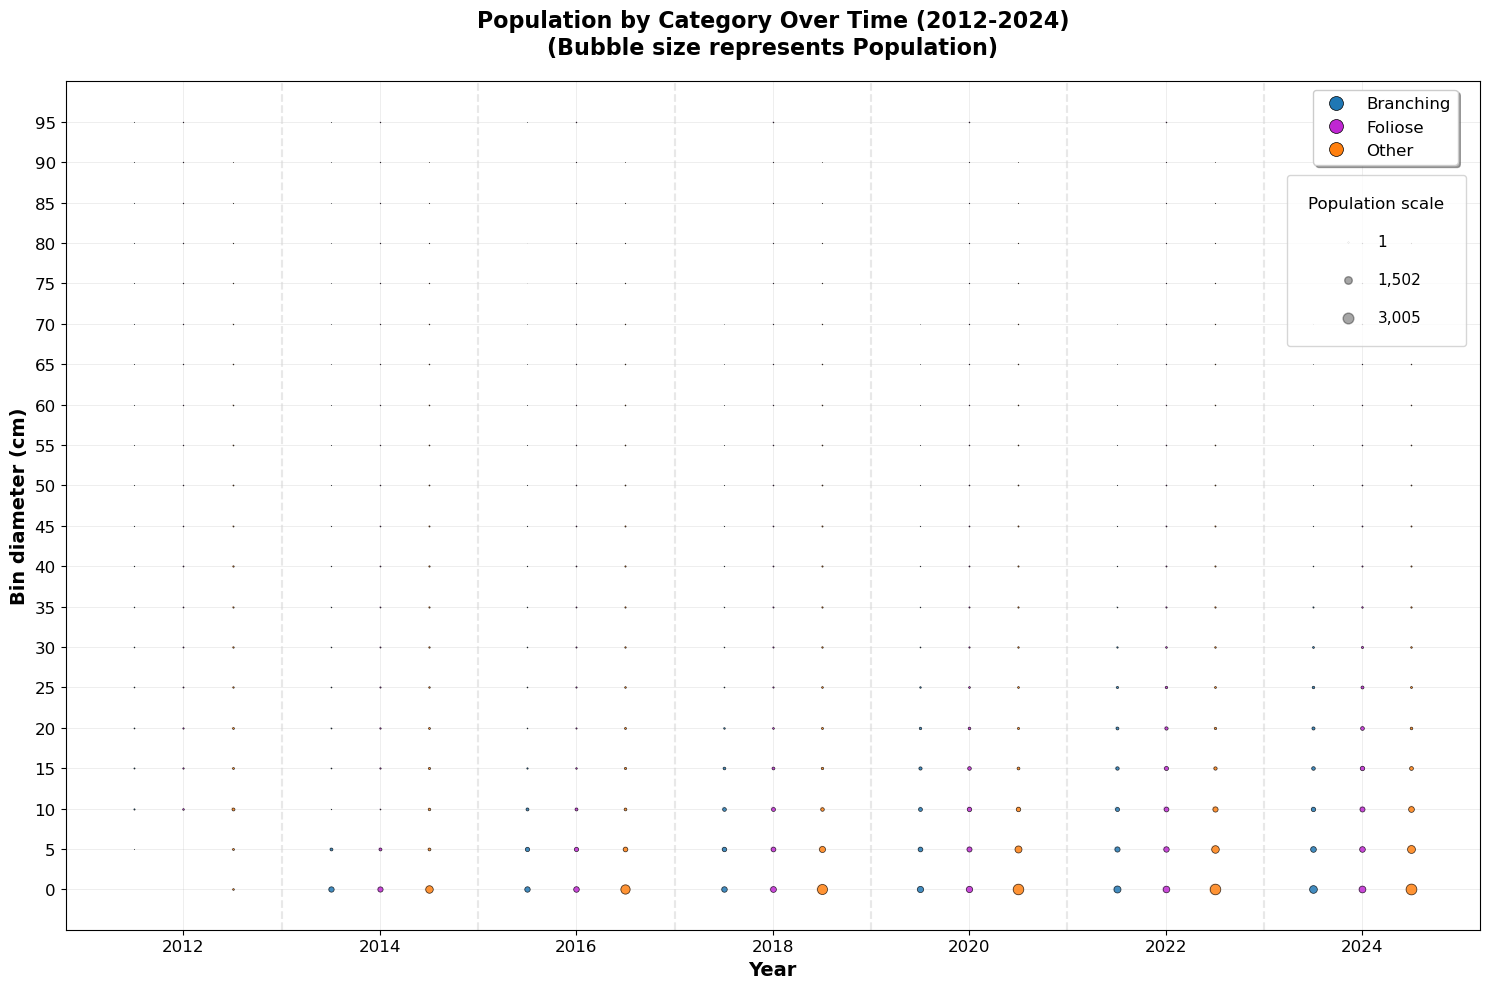

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population by Category Over Time (2012-2024)\n(Bubble size represents Population)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [23]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.08,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for percentage of population distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12]
Actual years for display: [2012, 2014, 2016, 2018, 2020, 2022, 2024]


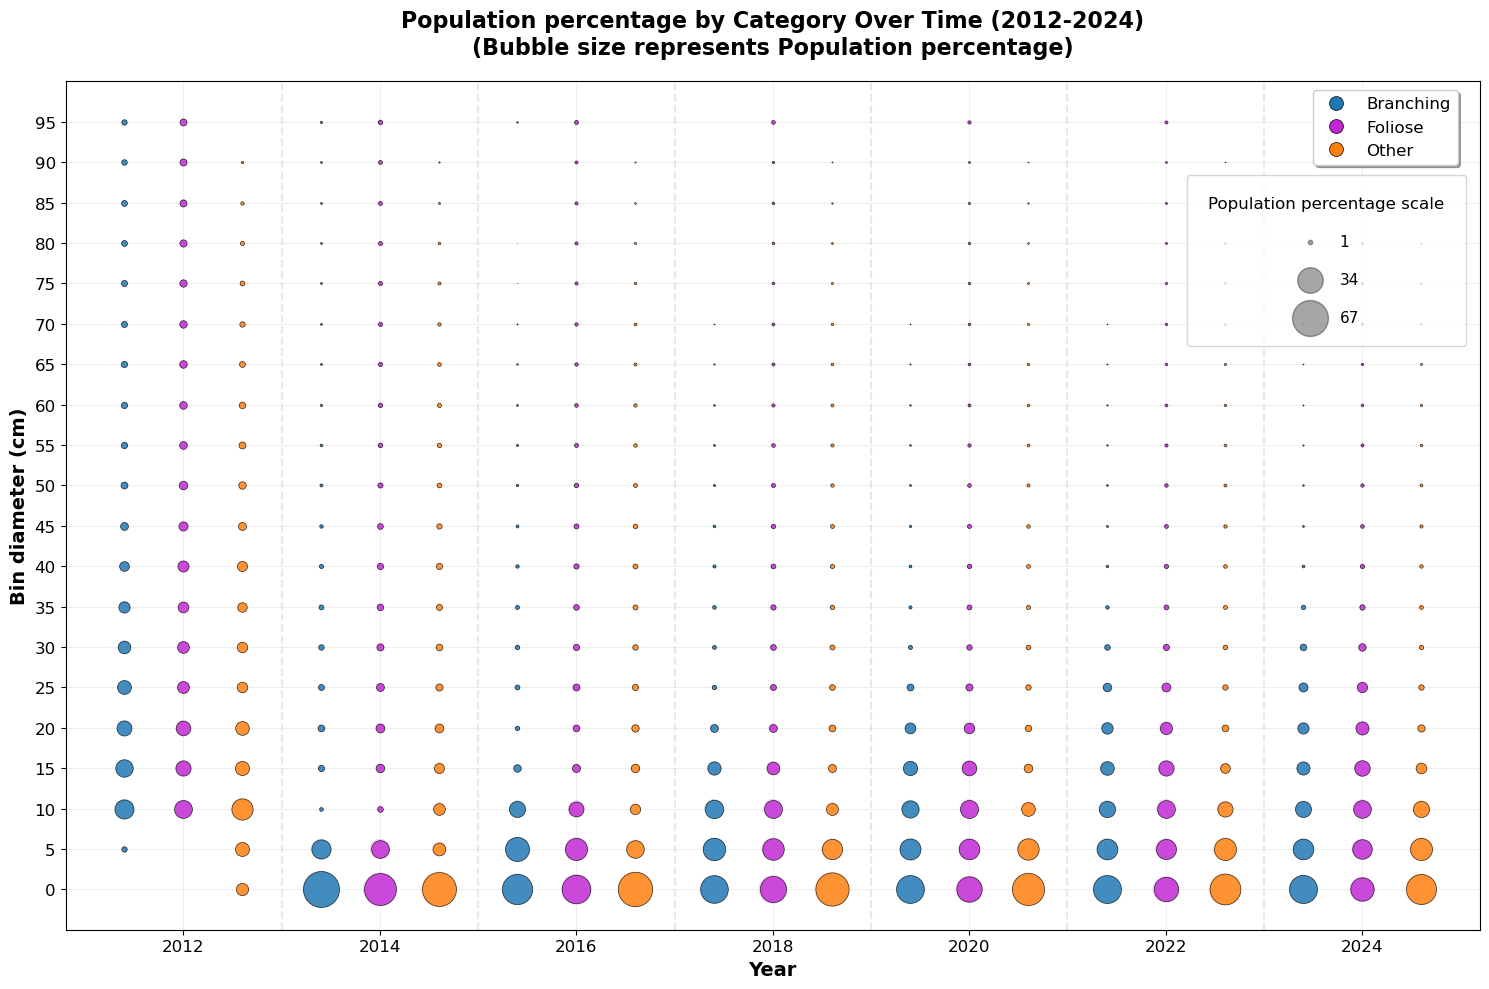

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population percentage by Category Over Time (2012-2024)\n(Bubble size represents Population percentage)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [24]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                year_interval=2,  
                                bubble_scale=10,
                                parallel_offset = 0.6,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.1,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for area distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12]
Actual years for display: [2012, 2014, 2016, 2018, 2020, 2022, 2024]


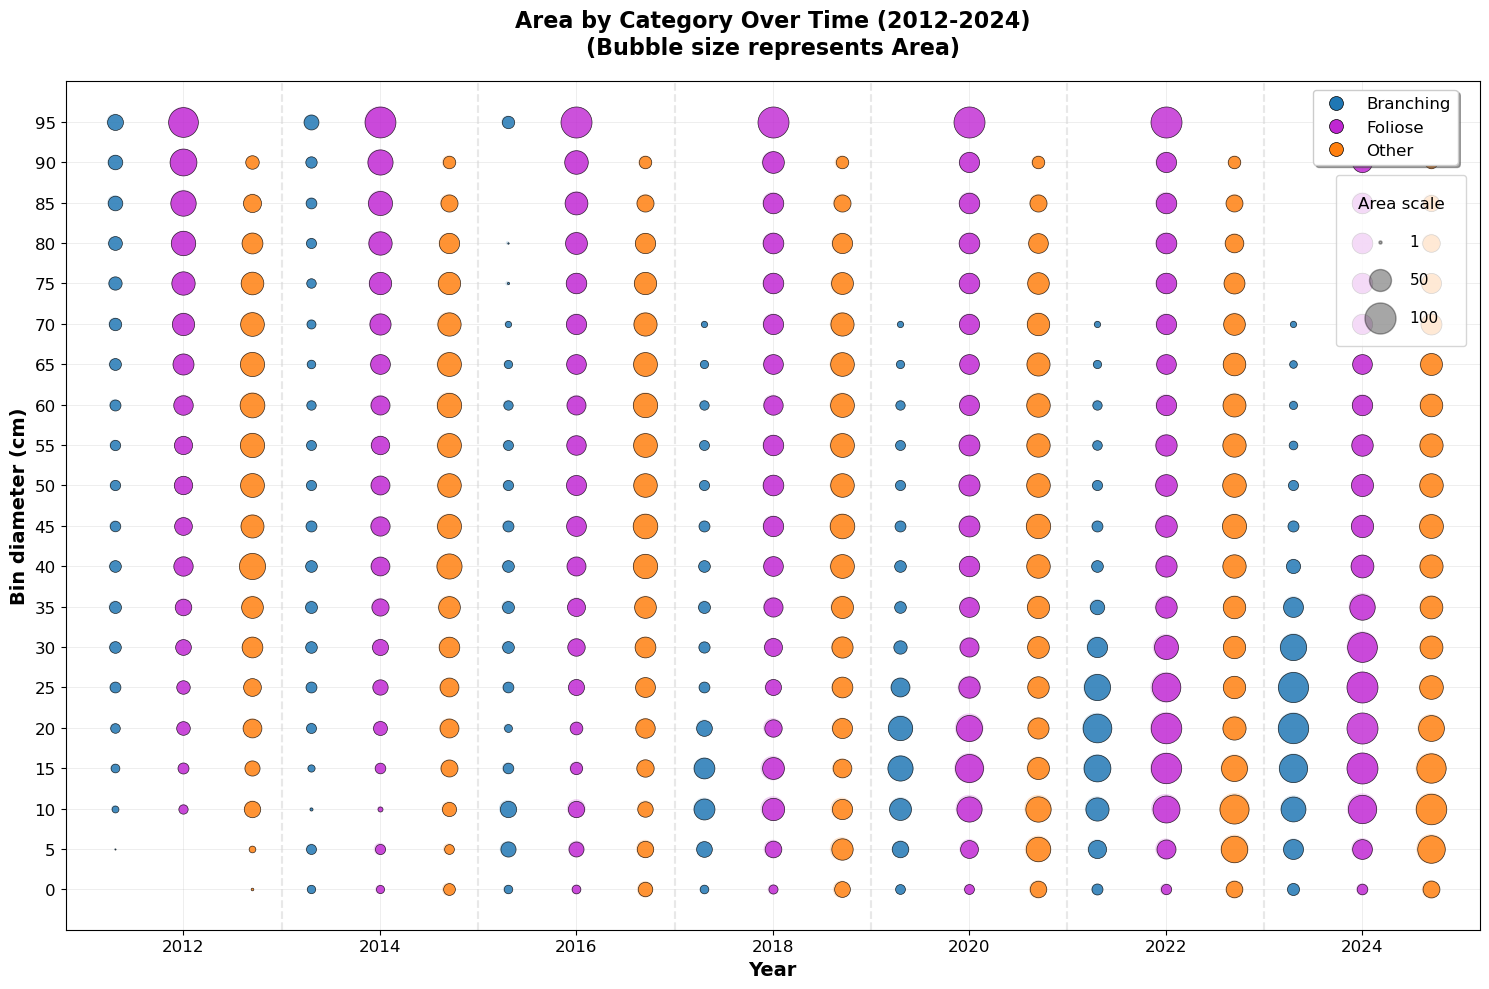

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Area by Category Over Time (2012-2024)\n(Bubble size represents Area)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [25]:
plot_bubble_chart_from_dataframe(area_df, 
                                title = "Area",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=5,
                                parallel_offset = 0.7,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.7,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Calculate and plot average and standard deviation for each morphology based on multiple iterations of model

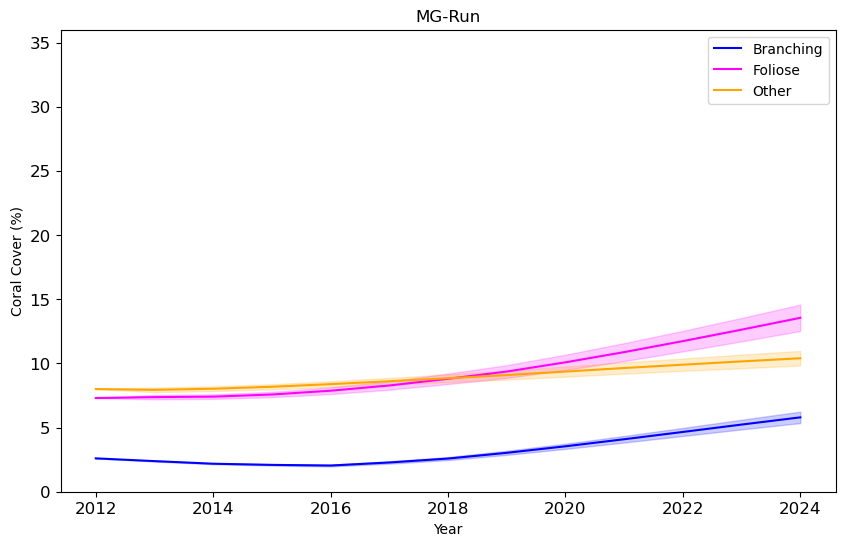

Graph has been saved to output/figures/MG-Run.png


In [26]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

## Plot substrate based on multiple iterations

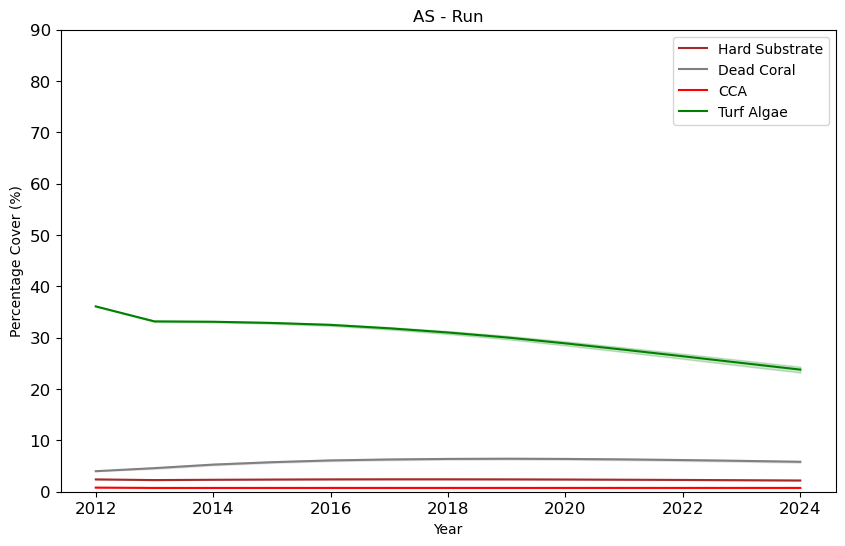

AS graph has been saved to output/figures/AS-Run.png


In [27]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

## Plot benthic cover based on multiple iterations

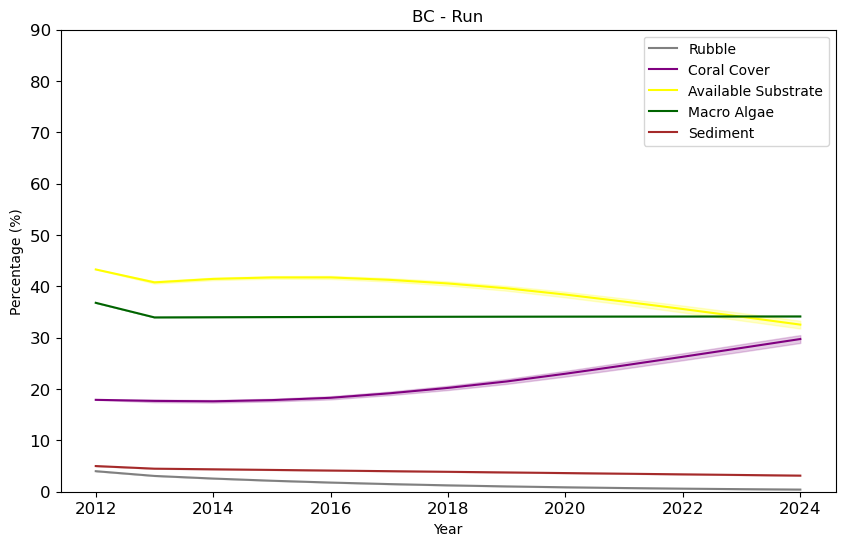

BC graph has been saved to output/figures/BC-Run.png


In [28]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years_model = average_rubble.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)  

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

## Plot rugosity based on multiple iterations

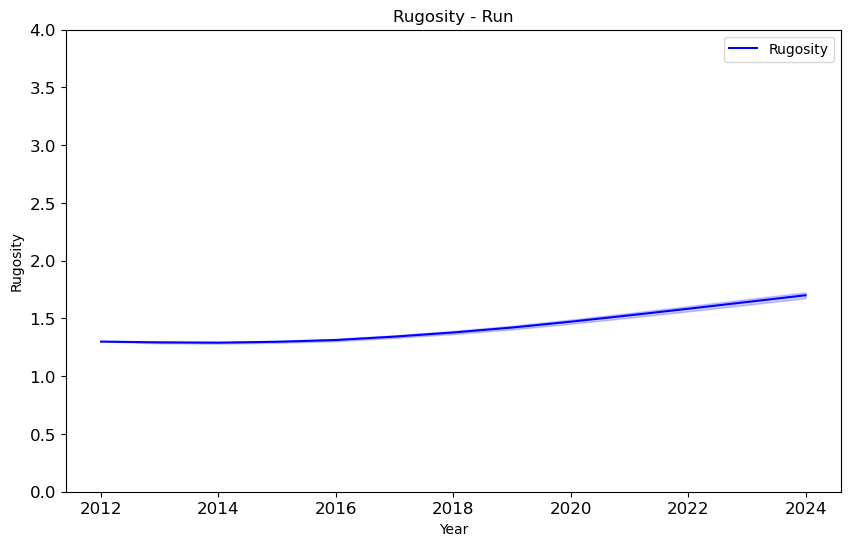

Rugosity graph has been saved to output/figures/Rugosity-Run.png


In [29]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years_model = average_rugosity.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int) 

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")

## Predicting the effect of a cyclone on the whole colony mortality

In [30]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

,Branching,Foliose,Other
0,0.200,0.20,0.20
1,0.148,0.04,0.04
2,0.148,0.04,0.04
3,0.076,0.04,0.04
4,0.076,0.02,0.02
5,0.076,0.02,0.02
6,0.076,0.02,0.02
7,0.076,0.02,0.02
8,0.076,0.02,0.02
9,0.076,0.02,0.02


## The effect of bleaching on the partial colony mortality

In [31]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms

ModuleNotFoundError: No module named 'winsound'